In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import time
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("MovieLens Analysis") \
    .getOrCreate()

movies = spark.read.csv(r"C:\Users\User\Desktop\Mag1\Big data\Homeworks\Homework6_7\movie.csv", header=True, inferSchema=True)
ratings = spark.read.csv(r"C:\Users\User\Desktop\Mag1\Big data\Homeworks\Homework6_7\rating.csv", header=True, inferSchema=True)

movies.cache()
ratings.cache()

movies.count()
ratings.count()

20000263

In [3]:
top_users = ratings.groupBy("userId") \
    .count() \
    .orderBy(desc("count")) \
    .limit(5)

top_users.show()

+------+-----+
|userId|count|
+------+-----+
|118205| 9254|
|  8405| 7515|
| 82418| 5646|
|121535| 5520|
|125794| 5491|
+------+-----+



In [4]:
movie_stats = ratings.groupBy("movieId") \
    .agg(
        avg("rating").alias("avg_rating"),
        count("*").alias("num_ratings")
    )

top_movies = movie_stats.filter(col("num_ratings") > 100) \
    .orderBy(desc("avg_rating")) \
    .limit(5) \
    .join(movies, "movieId")

top_movies.select("title", "avg_rating", "num_ratings").show()

+--------------------+-----------------+-----------+
|               title|       avg_rating|num_ratings|
+--------------------+-----------------+-----------+
|Usual Suspects, T...|4.334372207803259|      47006|
|Shawshank Redempt...|4.446990499637029|      63366|
|Schindler's List ...|4.310175010988133|      50054|
|Godfather, The (1...|4.364732196832306|      41355|
|Godfather: Part I...|4.275640557704942|      27398|
+--------------------+-----------------+-----------+



In [5]:
popular_movies = movie_stats.filter(
    (col("num_ratings") > 500) & (col("avg_rating") > 3.5)
)

popular_movies.join(movies, "movieId") \
    .select("title", "avg_rating", "num_ratings") \
    .show()

+--------------------+------------------+-----------+
|               title|        avg_rating|num_ratings|
+--------------------+------------------+-----------+
|Men in Black (a.k...|  3.55831928049466|      35580|
|    King Kong (1933)|3.5492681454655197|       6627|
| Galaxy Quest (1999)| 3.600717102904267|      13945|
|Hudsucker Proxy, ...|3.6641817536386228|      11268|
|Buddy Holly Story...| 3.605188343994314|       1407|
|Across the Univer...|3.6701244813278007|       1687|
|Before Sunset (2004)|3.9375181211945494|       3449|
|Out of Africa (1985)| 3.628987240829346|       5016|
|   Local Hero (1983)|  3.96665623043206|       3194|
|American Splendor...| 3.809135399673736|       3678|
|Tale of Two Siste...| 3.629032258064516|        620|
|Searching for Sug...| 3.943820224719101|        534|
| 3:10 to Yuma (1957)| 3.637745974955277|        559|
|Godfather, The (1...| 4.364732196832306|      41355|
|Bonnie and Clyde ...| 3.886447078569181|       9533|
|   Abyss, The (1989)|3.6580

In [6]:
ratings_with_day = ratings.withColumn(
    "day_of_week",
    date_format("timestamp", "EEEE")
)

genres = movies.withColumn(
    "genre", explode(split("genres", "\\|"))
)

joined = ratings_with_day.join(genres, "movieId")

genre_counts = joined.groupBy("day_of_week", "genre") \
    .count()

window_spec = Window.partitionBy("day_of_week").orderBy(desc("count"))

top_genres = genre_counts.withColumn(
    "rank", row_number().over(window_spec)
).filter(col("rank") == 1)

top_genres.show()

+-----------+-----+-------+----+
|day_of_week|genre|  count|rank|
+-----------+-----+-------+----+
|     Friday|Drama|1204803|   1|
|     Monday|Drama|1381410|   1|
|   Saturday|Drama|1178612|   1|
|     Sunday|Drama|1302020|   1|
|   Thursday|Drama|1191297|   1|
|    Tuesday|Drama|1347704|   1|
|  Wednesday|Drama|1252007|   1|
+-----------+-----+-------+----+



In [7]:
ratings_day_type = ratings.withColumn(
    "day_type",
    when(
        date_format(col("timestamp"), "E").isin("Sat", "Sun"),
        "Weekend"
    ).otherwise("Weekday")
)

avg_rating_day = ratings_day_type.groupBy("day_type") \
    .agg(avg("rating").alias("avg_rating"))

avg_rating_day.show()

+--------+------------------+
|day_type|        avg_rating|
+--------+------------------+
| Weekday|3.5209676292566336|
| Weekend|  3.53746713028832|
+--------+------------------+



In [8]:
join_df = ratings.join(movies, "movieId")
join_df.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [movieId#38, userId#37, rating#39, timestamp#40, title#18, genres#19]
   +- BroadcastHashJoin [movieId#38], [movieId#17], Inner, BuildRight, false
      :- Filter isnotnull(movieId#38)
      :  +- InMemoryTableScan [userId#37, movieId#38, rating#39, timestamp#40], [isnotnull(movieId#38)]
      :        +- InMemoryRelation [userId#37, movieId#38, rating#39, timestamp#40], StorageLevel(disk, memory, deserialized, 1 replicas)
      :              +- FileScan csv [userId#37,movieId#38,rating#39,timestamp#40] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/User/Desktop/Mag1/Big data/Homeworks/Homework6_7/rating..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<userId:int,movieId:int,rating:double,timestamp:timestamp>
      +- BroadcastExchange HashedRelationBroadcastMode(List(cast(input[0, int, false] as bigint)),false), [plan_id=1148]
         +- Filter isnotnu

In [9]:
broadcast_join = ratings.join(broadcast(movies), "movieId")
broadcast_join.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [movieId#38, userId#37, rating#39, timestamp#40, title#18, genres#19]
   +- BroadcastHashJoin [movieId#38], [movieId#17], Inner, BuildRight, false
      :- Filter isnotnull(movieId#38)
      :  +- InMemoryTableScan [userId#37, movieId#38, rating#39, timestamp#40], [isnotnull(movieId#38)]
      :        +- InMemoryRelation [userId#37, movieId#38, rating#39, timestamp#40], StorageLevel(disk, memory, deserialized, 1 replicas)
      :              +- FileScan csv [userId#37,movieId#38,rating#39,timestamp#40] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/User/Desktop/Mag1/Big data/Homeworks/Homework6_7/rating..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<userId:int,movieId:int,rating:double,timestamp:timestamp>
      +- BroadcastExchange HashedRelationBroadcastMode(List(cast(input[0, int, false] as bigint)),false), [plan_id=1171]
         +- Filter isnotnu

In [10]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

no_broadcast = ratings.join(movies, "movieId")
no_broadcast.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [movieId#38, userId#37, rating#39, timestamp#40, title#18, genres#19]
   +- SortMergeJoin [movieId#38], [movieId#17], Inner
      :- Sort [movieId#38 ASC NULLS FIRST], false, 0
      :  +- Exchange hashpartitioning(movieId#38, 200), ENSURE_REQUIREMENTS, [plan_id=1195]
      :     +- Filter isnotnull(movieId#38)
      :        +- InMemoryTableScan [userId#37, movieId#38, rating#39, timestamp#40], [isnotnull(movieId#38)]
      :              +- InMemoryRelation [userId#37, movieId#38, rating#39, timestamp#40], StorageLevel(disk, memory, deserialized, 1 replicas)
      :                    +- FileScan csv [userId#37,movieId#38,rating#39,timestamp#40] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/User/Desktop/Mag1/Big data/Homeworks/Homework6_7/rating..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<userId:int,movieId:int,rating:double,timestamp:timestamp>
 

In [11]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def category(r):
    if r >= 4:
        return "Good"
    elif r >= 2:
        return "Average"
    return "Bad"

udf_func = udf(category, StringType())

start = time.time()
df_udf = ratings.withColumn("cat", udf_func("rating"))
df_udf.count()
udf_time = time.time() - start

In [12]:
@pandas_udf("string")
def pandas_cat(r):
    return r.apply(lambda x: "Good" if x >= 4 else ("Average" if x >= 2 else "Bad"))

start = time.time()
df_pandas = ratings.withColumn("cat", pandas_cat("rating"))
df_pandas.count()
pandas_time = time.time() - start

In [13]:
start = time.time()

df_builtin = ratings.withColumn(
    "cat",
    when(col("rating") >= 4, "Good")
    .when(col("rating") >= 2, "Average")
    .otherwise("Bad")
)

df_builtin.count()
builtin_time = time.time() - start

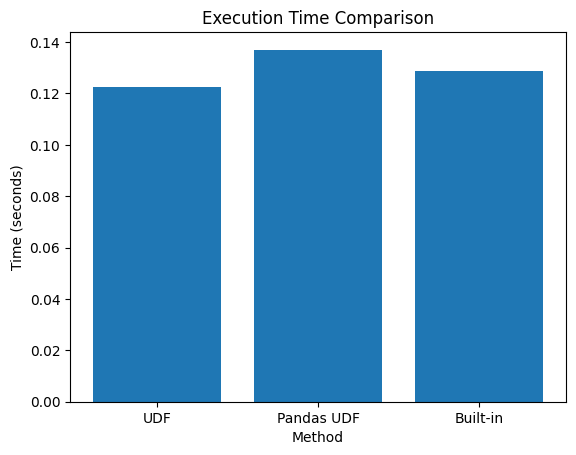

In [14]:
methods = ["UDF", "Pandas UDF", "Built-in"]
times = [udf_time, pandas_time, builtin_time]

plt.bar(methods, times)
plt.title("Execution Time Comparison")
plt.xlabel("Method")
plt.ylabel("Time (seconds)")
plt.show()

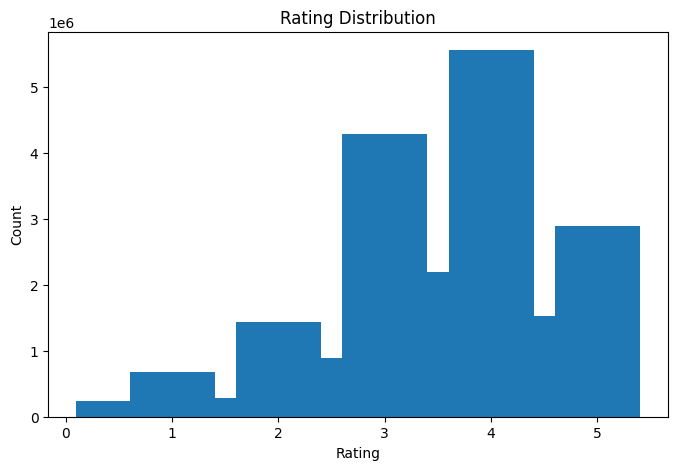

In [15]:
rating_counts = ratings.groupBy("rating").count().orderBy("rating").toPandas()

plt.figure(figsize=(8,5))
plt.bar(rating_counts["rating"], rating_counts["count"])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()